In [24]:
# import mitsuba
import mitsuba as mi, math

import numpy as np
import matplotlib.pyplot as plt


In [25]:
mi.variants()

['scalar_rgb',
 'scalar_spectral',
 'scalar_spectral_polarized',
 'llvm_ad_rgb',
 'llvm_ad_mono',
 'llvm_ad_mono_polarized',
 'llvm_ad_spectral',
 'llvm_ad_spectral_polarized',
 'cuda_ad_rgb',
 'cuda_ad_mono',
 'cuda_ad_mono_polarized',
 'cuda_ad_spectral',
 'cuda_ad_spectral_polarized']

In [26]:
mi.set_variant('scalar_rgb')

from mitsuba import ScalarTransform4f as T

In [27]:
help(mi.traverse)

Help on function traverse in module mitsuba.python.util:

traverse(node: 'mi.Object') -> 'SceneParameters'
    Traverse a node of Mitsuba's scene graph and return a dictionary-like
    object that can be used to read and write associated scene parameters.

    See also :py:class:`mitsuba.SceneParameters`.



In [28]:
def load_sensor(r, phi, theta):
    y = r*np.sin(math.radians(theta))
    x = r*np.cos(math.radians(theta))*np.sin(math.radians(phi))
    z = r*np.cos(math.radians(theta))*np.cos(math.radians(phi))
    
    origin = np.array([x, y, z])
    
    return mi.load_dict({
        'type': 'perspective',
        'fov': 40,
        'to_world': T().look_at(
            origin=origin,
            target=[0, 0, 0],
            up=[0, 1, 0]
        ),
        'sampler': {
            'type': 'independent',
            'sample_count': 16
        },
        'film': {
            'type': 'hdrfilm',
            'width': 256,
            'height': 256,
            'rfilter': {
                'type': 'tent',
            },
            'pixel_format': 'rgb',
        },
    })


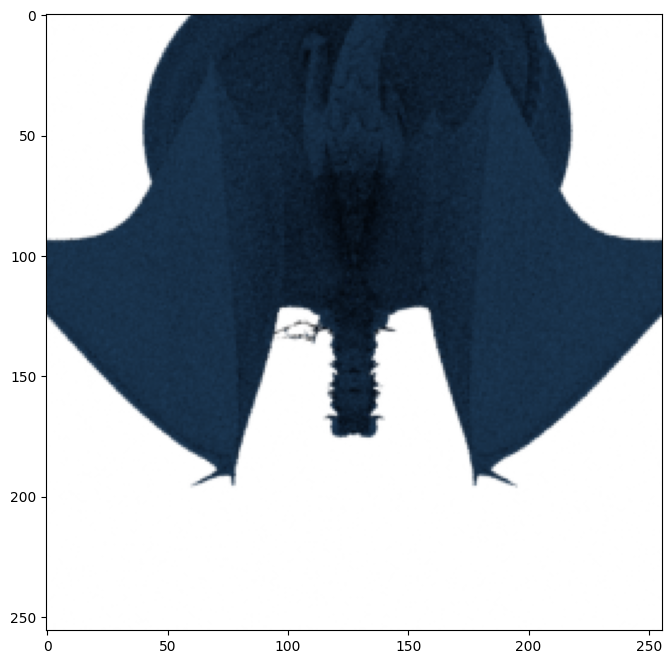

In [29]:
dragon = {
    'type': 'obj',
    'filename': 'scenes/objects/dragon.obj',
    'to_world': T().translate([0, -5, 0]),
    'bsdf': {
        'type': 'diffuse',
        'reflectance': {
            'type': 'rgb', 
            'value': [0.1, 0.2, 0.3]
        }
    }
}

scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'path',
    },
    'emitter': {
        'type' : 'constant'
    },
    'dragon': dragon,
})

r = 35
phis = np.linspace(0, 360, 20)
theta = 45

sensores = []
for phi in phis:
    sensor = load_sensor(r, phi, theta)
    sensores.append(sensor)


imagenes = []
for sensor in sensores:
    imagen = mi.render(scene, sensor=sensor, spp=16)
    imagenes.append(imagen)

plt.figure(figsize=(8, 8))
plt.imshow(imagenes[0])

plt.show()

0.011246255 1.0
(256, 256, 3)


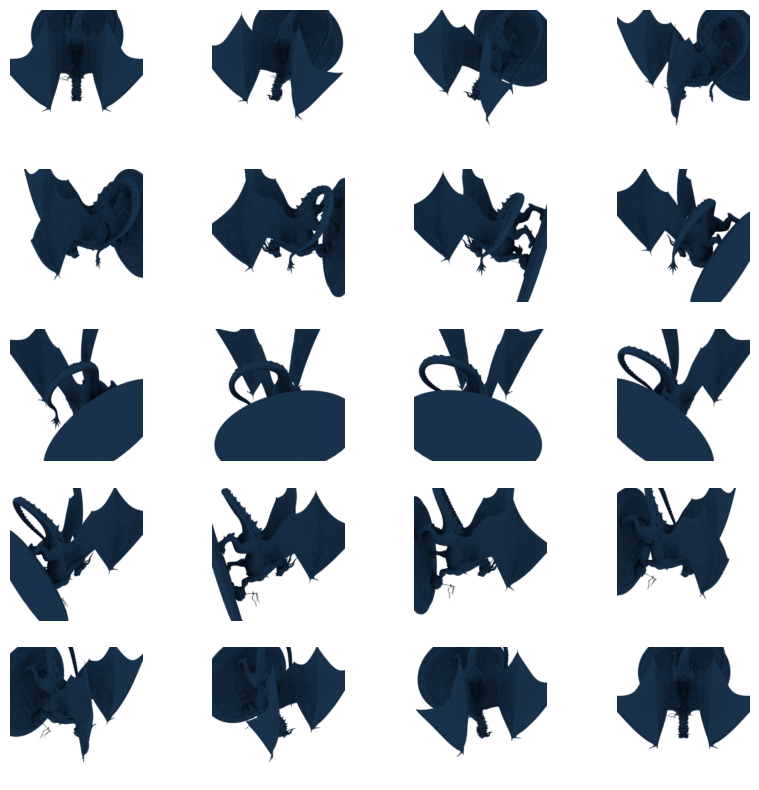

In [30]:
print(np.min(imagenes[0]), np.max(imagenes[0]))
print(imagenes[0].shape)


# plot
plt.figure(figsize=(10, 10))
for i, imagen in enumerate(imagenes):
    plt.subplot(5, 4, i+1)
    plt.imshow(imagen)
    plt.axis('off')

In [31]:
dict_pre = mi.cornell_box()

print(dict_pre)

{'type': 'scene', 'integrator': {'type': 'path', 'max_depth': 8}, 'sensor': {'type': 'perspective', 'fov_axis': 'smaller', 'near_clip': 0.001, 'far_clip': 100.0, 'focus_distance': 1000, 'fov': 39.3077, 'to_world': Transform[
  matrix=[[-1, 0, 0, 0],
          [0, 1, 0, 0],
          [0, 0, -1, 3.9],
          [0, 0, 0, 1]],
  inverse_transpose=[[-1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, -1, 0],
                     [0, 0, 3.9, 1]]
], 'sampler': {'type': 'independent', 'sample_count': 64}, 'film': {'type': 'hdrfilm', 'width': 256, 'height': 256, 'rfilter': {'type': 'gaussian'}, 'pixel_format': 'rgb', 'component_format': 'float32'}}, 'white': {'type': 'diffuse', 'reflectance': {'type': 'rgb', 'value': [0.885809, 0.698859, 0.666422]}}, 'green': {'type': 'diffuse', 'reflectance': {'type': 'rgb', 'value': [0.105421, 0.37798, 0.076425]}}, 'red': {'type': 'diffuse', 'reflectance': {'type': 'rgb', 'value': [0.570068, 0.0430135, 0.0443706]}}, 'light': {'type':

In [32]:
def load_sensor(r, phi, theta):
    z = r*np.sin(math.radians(theta))
    y = r*np.cos(math.radians(theta))*np.sin(math.radians(phi))
    x = r*np.cos(math.radians(theta))*np.cos(math.radians(phi))
    
    origin = np.array([x, y, z])
    
    return mi.load_dict({
        'type': 'perspective',
        'fov': 40,
        'to_world': T().look_at(
            origin=origin,
            target=[0, 0, 0],
            up=[0, 0, 1]
        ),
        'sampler': {
            'type': 'independent',
            'sample_count': 16
        },
        'film': {
            'type': 'hdrfilm',
            'width': 256,
            'height': 256,
            'rfilter': {
                'type': 'tent',
            },
            'pixel_format': 'rgb',
        },
    })

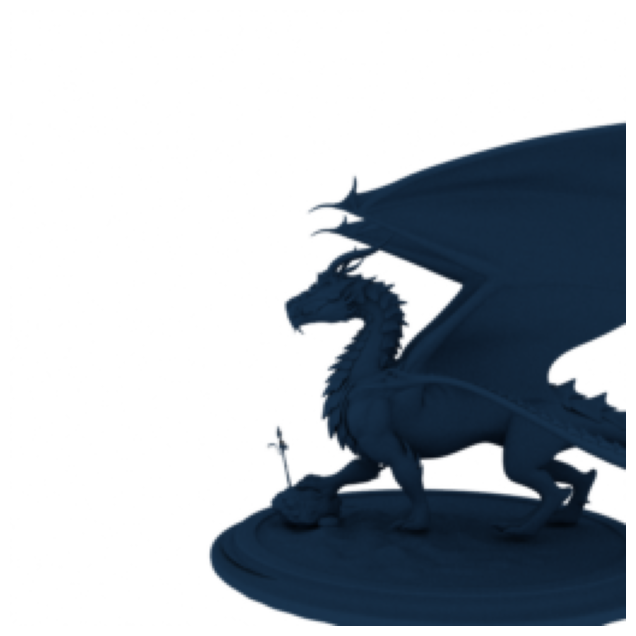

In [ ]:
dragon = {
    'type': 'obj',
    'filename': 'scenes/objects/dragon.obj',
    'to_world': T().translate([0, 0, 0]),
    'bsdf': {
        'type': 'diffuse',
        'reflectance': {
            'type': 'rgb', 
            'value': [0.1, 0.2, 0.3]
        }
    }
}

scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'path',
    },
    'emitter': {
        'type' : 'constant'
    },
    'dragon': dragon,
})

r = 40
phis = np.linspace(0, 360, 20)
theta = 0

sensores = []
for phi in phis:
    sensor = load_sensor(r, phi, theta)
    sensores.append(sensor)


imagenes = []
for sensor in sensores:
    imagen = mi.render(scene, sensor=sensor, spp=512)
    imagenes.append(imagen)

plt.figure(figsize=(8, 8))
plt.imshow(imagenes[0])
plt.axis('off')

plt.show()

0.0067602554 1.0
(256, 256, 3)


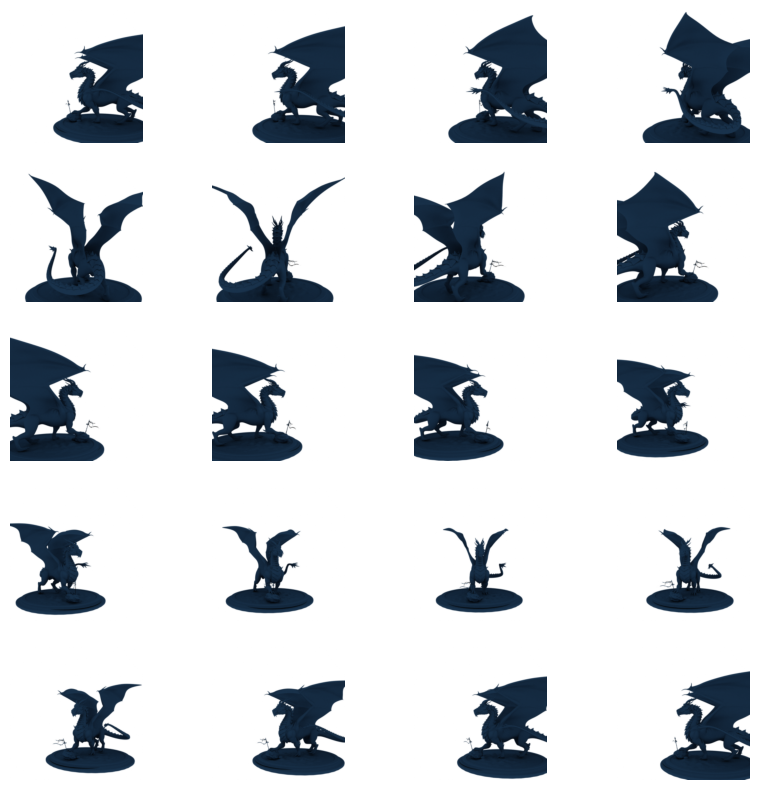

In [34]:
print(np.min(imagenes[0]), np.max(imagenes[0]))
print(imagenes[0].shape)


# plot
plt.figure(figsize=(10, 10))
for i, imagen in enumerate(imagenes):
    plt.subplot(5, 4, i+1)
    plt.imshow(imagen)
    plt.axis('off')